# CN7 모델 비교 — 가능한 모델을 모두 시도해 성능 끌어올리기

`CN7.ipynb`(데이터 진단 · 이상탐지 · 검사 우선순위)에 이어, **지도학습 · 불균형 대응 · 이상탐지 · 튜닝 · 앙상블**을 같은 교차검증으로 비교한다.
계산은 `run_models.py`(모델 정의는 `model_zoo.py`)가 하고, 이 노트북은 결과를 읽어 해석한다.

| 구분 | 지표 | 계산 |
|---|---|---|
| **주 지표** | **PR-AUC**, **Recall@k%** (k = 10, 20, 30) | 평가 fold별 → 50개 fold 평균 ± 표준편차 |
| **손익 분석용** | **검사율@재현율** (0.9, 1.0) | fold당 불량이 3~4개라 fold 안에서는 0.9 = 1.0이 된다 → 반복마다 5개 fold 점수를 fold 안 백분위로 바꿔 모은 뒤 불량 전체로 계산 (10회 평균 ± 표준편차) |
| 참고 | F1, Recall, Precision, ROC-AUC | F1·Recall·Precision의 임계값은 **학습 fold 안 3-fold 예측**에서 F1 최대점으로 정함 (평가 fold 미사용) |

## 1. 평가 설계

**평가 두 가지** — `CN7.ipynb` 8-2 (b-2)에서 불량 17개가 모두 샷 24~60에 몰려 있고, 그 시기가 공정 값으로 거의 완벽히 구분됨(ROC-AUC 0.98)을 확인했다. 전체 기간 평가는 "불량 시기 찾기"를 성능으로 셀 수 있으므로 판정은 E2로 한다.

| 평가 | 데이터 | 역할 |
|---|---|---|
| E1 전체 기간 | labeled 1,211부품 (606샷), `shot_id` 묶음 층화 5-fold × 10회 (`CN7.ipynb` 5-1과 같은 분할) | 참고 (팀 공통 방식) |
| **E2 불량 시기 안** | 샷 0~60 (121부품, 불량 17), 같은 분할 방식 | **판정용** — 시기 효과를 뺀 평가 |

**기준선** — 모델이 넘어야 할 선
- 무작위 / 쌍 순서 규칙(앞쪽 부품 위험) / **샷 순서**(방향은 학습 fold에서 결정). 샷 순서를 넘지 못하면 모델은 공정 값이 아니라 **시간**을 맞힌 것이다.

**피처 두 가지** — 공정 값 23개 / 공정 값 23개 + `pair_pos`(쌍 순서, 해석 A: 부품 위치 가정)

**누수 방지**
- 같은 샷의 두 부품(공정 값 동일)은 항상 같은 fold. 튜닝·스태킹·임계값의 **내부 CV도 샷 단위**로 묶는다 (sklearn `StackingClassifier`의 내부 CV는 샷을 묶지 않아 직접 구현).
- 표준화·오버샘플링(SMOTE·ADASYN)·언더샘플링은 학습 fold 안에서만.
- 튜닝은 **중첩 교차검증**: 학습 fold 안 3-fold로 후보 설정(최대 12개)의 PR-AUC를 비교해 고른다.

### 시도한 모델 (36종)

| 계열 | 모델 |
|---|---|
| 선형·확률 | 로지스틱 (L2 / L1 / ElasticNet), LDA (shrinkage), 나이브 베이즈 |
| 거리·커널·신경망 | kNN, SVM (선형 / RBF), MLP |
| 트리·부스팅 | 결정트리, 랜덤포레스트, 엑스트라트리, AdaBoost, GradientBoosting, HistGradientBoosting, XGBoost, LightGBM, CatBoost |
| 불균형 대응 | SMOTE + 로지스틱, ADASYN + 로지스틱, SMOTE + 랜덤포레스트, Balanced 랜덤포레스트, EasyEnsemble, RUSBoost |
| 이상탐지 (학습 fold 양품만 학습) | Isolation Forest, LOF, One-Class SVM, Elliptic Envelope |
| 튜닝 (중첩 CV) | 로지스틱, 랜덤포레스트, XGBoost, LightGBM, CatBoost |
| 앙상블 | 스태킹 (LR·SVM·RF → LR), 순위 평균 5종 (**사전 고정**: 로지스틱 L2·SVM RBF·랜덤포레스트·엑스트라트리·CatBoost), 부스팅 튜닝 3종 평균 (**사후 선택** → 낙관적일 수 있음) |

- 시도하지 못한 것: **TabPFN**(소표본 표 데이터용 사전학습 모델)은 가중치를 받으려면 사용자 계정의 라이선스 동의·로그인이 필요해 제외했다. 준지도학습은 unlabeled가 다른 기간·운전 조건이라(`CN7.ipynb` 3-6) 제외했다.
- 모델 기본 설정은 소표본·불균형에 맞춘 보수적 값으로 정하고, 결과를 보고 고치지 않았다.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

installed_fonts = {f.name for f in font_manager.fontManager.ttflist}
plt.rcParams['font.family'] = next((f for f in ['Malgun Gothic', 'AppleGothic', 'NanumGothic'] if f in installed_fonts), 'DejaVu Sans')
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)

C_MAIN, C_SUB = '#2a78d6', '#eb6834'
C_INK, C_GRID = '#52514e', '#e6e5e0'
plt.rcParams.update({
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': C_GRID, 'axes.labelcolor': C_INK,
    'xtick.color': C_INK, 'ytick.color': C_INK,
    'axes.grid': True, 'grid.color': C_GRID, 'grid.linewidth': 0.6,
    'axes.titlesize': 10,
})

TABLES = Path('outputs/tables')
RUN = False  # True: 모델 비교를 다시 계산 (24코어 기준 약 30분). False: 저장된 결과 사용

if RUN:
    import run_models
    run_models.compare()
    run_models.time_increment()

summary = pd.read_csv(TABLES / 'model_summary.csv')
increment = pd.read_csv(TABLES / 'time_increment.csv', index_col=0)
EVALS = summary['eval'].unique().tolist()
print(EVALS)

['E1 전체 기간', 'E2 불량 시기 안 (샷 0~60)']


In [2]:
MAIN = ['PR-AUC', 'Recall@10%', 'Recall@20%', 'Recall@30%']
COST = ['검사율@재현율0.9', '검사율@재현율1']
REF = ['F1', 'Recall', 'Precision', 'ROC-AUC']


def table(eval_name, features):
    """한 설정의 결과표 (기준선 포함, PR-AUC 내림차순). 값 = 평균 ± 표준편차"""
    d = summary[(summary['eval'] == eval_name) & summary['features'].isin([features, '-'])].copy()
    d = d.sort_values('PR-AUC_mean', ascending=False).set_index('model')
    out = pd.DataFrame({m: d[f'{m}_mean'].map('{:.3f}'.format) + ' ± ' + d[f'{m}_std'].map('{:.3f}'.format)
                        for m in MAIN + COST + REF})
    out.insert(0, '계열', d['family'])
    if d['failed_folds'].sum():
        out['학습 실패 fold'] = d['failed_folds']
    return out

## 2. E2 불량 시기 안 (판정용)

샷 0~60 (121부품, 불량 17)만으로 평가한다. fold당 평가 부품은 약 24개, 불량 3~4개라 fold 간 흔들림이 크다 (표준편차 참고).

In [3]:
table(EVALS[1], '공정 값 23')

,계열,PR-AUC,Recall@10%,Recall@20%,Recall@30%,검사율@재현율0.9,검사율@재현율1,F1,Recall,Precision,ROC-AUC,학습 실패 fold
model,,,,,,,,,,,,
[기준] 샷 순서,기준선,0.766 ± 0.184,0.597 ± 0.196,0.842 ± 0.151,0.920 ± 0.138,0.291 ± 0.061,0.563 ± 0.151,0.656 ± 0.176,0.745 ± 0.256,0.619 ± 0.173,0.927 ± 0.072,0
LightGBM,부스팅,0.641 ± 0.239,0.505 ± 0.226,0.678 ± 0.242,0.805 ± 0.227,0.445 ± 0.128,0.580 ± 0.132,0.395 ± 0.306,0.447 ± 0.359,0.404 ± 0.357,0.865 ± 0.104,0
LightGBM (튜닝),튜닝,0.609 ± 0.230,0.485 ± 0.230,0.587 ± 0.237,0.750 ± 0.234,0.542 ± 0.145,0.645 ± 0.154,0.366 ± 0.276,0.492 ± 0.370,0.352 ± 0.331,0.829 ± 0.120,0
SMOTE + 랜덤포레스트,불균형,0.598 ± 0.250,0.483 ± 0.242,0.587 ± 0.256,0.675 ± 0.232,0.694 ± 0.104,0.747 ± 0.108,0.351 ± 0.324,0.385 ± 0.365,0.359 ± 0.360,0.786 ± 0.136,0
부스팅 튜닝 3종 평균 (사후 선택),앙상블,0.597 ± 0.232,0.470 ± 0.226,0.582 ± 0.217,0.687 ± 0.235,0.591 ± 0.124,0.665 ± 0.139,0.412 ± 0.268,0.510 ± 0.343,0.418 ± 0.342,0.813 ± 0.120,0
스태킹 (LR·SVM·RF → LR),앙상블,0.588 ± 0.230,0.460 ± 0.238,0.557 ± 0.210,0.653 ± 0.220,0.613 ± 0.090,0.745 ± 0.124,0.342 ± 0.243,0.498 ± 0.368,0.311 ± 0.280,0.796 ± 0.122,0
랜덤포레스트,트리,0.581 ± 0.241,0.455 ± 0.230,0.513 ± 0.213,0.617 ± 0.221,0.546 ± 0.110,0.653 ± 0.173,0.360 ± 0.303,0.400 ± 0.349,0.404 ± 0.402,0.799 ± 0.124,0
Balanced 랜덤포레스트,불균형,0.570 ± 0.242,0.448 ± 0.229,0.563 ± 0.230,0.657 ± 0.231,0.592 ± 0.126,0.693 ± 0.112,0.346 ± 0.315,0.385 ± 0.341,0.378 ± 0.397,0.792 ± 0.125,0
XGBoost,부스팅,0.568 ± 0.226,0.438 ± 0.223,0.583 ± 0.208,0.712 ± 0.219,0.588 ± 0.133,0.735 ± 0.088,0.389 ± 0.257,0.455 ± 0.315,0.400 ± 0.317,0.801 ± 0.121,0


In [4]:
table(EVALS[1], '공정 값 23 + pair_pos')

,계열,PR-AUC,Recall@10%,Recall@20%,Recall@30%,검사율@재현율0.9,검사율@재현율1,F1,Recall,Precision,ROC-AUC,학습 실패 fold
model,,,,,,,,,,,,
[기준] 샷 순서,기준선,0.766 ± 0.184,0.597 ± 0.196,0.842 ± 0.151,0.920 ± 0.138,0.291 ± 0.061,0.563 ± 0.151,0.656 ± 0.176,0.745 ± 0.256,0.619 ± 0.173,0.927 ± 0.072,0
LightGBM,부스팅,0.745 ± 0.201,0.610 ± 0.200,0.775 ± 0.193,0.898 ± 0.160,0.376 ± 0.117,0.752 ± 0.074,0.538 ± 0.268,0.567 ± 0.322,0.589 ± 0.330,0.900 ± 0.096,0
LightGBM (튜닝),튜닝,0.711 ± 0.177,0.553 ± 0.195,0.740 ± 0.203,0.838 ± 0.206,0.413 ± 0.123,0.735 ± 0.074,0.506 ± 0.243,0.580 ± 0.308,0.538 ± 0.314,0.880 ± 0.102,0
부스팅 튜닝 3종 평균 (사후 선택),앙상블,0.700 ± 0.200,0.542 ± 0.206,0.747 ± 0.211,0.855 ± 0.189,0.422 ± 0.140,0.721 ± 0.116,0.510 ± 0.226,0.565 ± 0.311,0.571 ± 0.311,0.880 ± 0.105,0
SMOTE + 랜덤포레스트,불균형,0.695 ± 0.210,0.598 ± 0.224,0.722 ± 0.204,0.778 ± 0.187,0.566 ± 0.105,0.795 ± 0.117,0.484 ± 0.317,0.502 ± 0.352,0.547 ± 0.385,0.853 ± 0.110,0
Balanced 랜덤포레스트,불균형,0.677 ± 0.215,0.558 ± 0.197,0.695 ± 0.209,0.765 ± 0.212,0.529 ± 0.104,0.679 ± 0.100,0.412 ± 0.290,0.482 ± 0.347,0.423 ± 0.352,0.856 ± 0.110,0
XGBoost,부스팅,0.674 ± 0.195,0.550 ± 0.173,0.712 ± 0.214,0.845 ± 0.187,0.426 ± 0.131,0.779 ± 0.114,0.530 ± 0.227,0.583 ± 0.316,0.564 ± 0.273,0.869 ± 0.108,0
스태킹 (LR·SVM·RF → LR),앙상블,0.669 ± 0.210,0.538 ± 0.222,0.648 ± 0.214,0.750 ± 0.198,0.574 ± 0.092,0.716 ± 0.128,0.435 ± 0.279,0.493 ± 0.335,0.448 ± 0.335,0.840 ± 0.115,0
랜덤포레스트,트리,0.669 ± 0.227,0.525 ± 0.214,0.643 ± 0.215,0.760 ± 0.235,0.512 ± 0.100,0.657 ± 0.092,0.415 ± 0.281,0.478 ± 0.340,0.434 ± 0.353,0.851 ± 0.114,0


## 3. E1 전체 기간 (참고)

In [5]:
table(EVALS[0], '공정 값 23')

,계열,PR-AUC,Recall@10%,Recall@20%,Recall@30%,검사율@재현율0.9,검사율@재현율1,F1,Recall,Precision,ROC-AUC,학습 실패 fold
model,,,,,,,,,,,,
LightGBM (튜닝),튜닝,0.525 ± 0.265,0.917 ± 0.158,0.993 ± 0.047,0.993 ± 0.047,0.094 ± 0.023,0.168 ± 0.096,0.290 ± 0.277,0.408 ± 0.380,0.285 ± 0.330,0.970 ± 0.030,0
LightGBM,부스팅,0.519 ± 0.263,0.877 ± 0.174,0.953 ± 0.135,0.980 ± 0.080,0.129 ± 0.060,0.240 ± 0.114,0.291 ± 0.296,0.372 ± 0.367,0.285 ± 0.332,0.961 ± 0.043,0
SMOTE + 로지스틱,불균형,0.496 ± 0.252,0.800 ± 0.231,0.932 ± 0.131,1.000 ± 0.000,0.189 ± 0.048,0.228 ± 0.038,0.352 ± 0.311,0.362 ± 0.307,0.400 ± 0.396,0.948 ± 0.043,0
부스팅 튜닝 3종 평균 (사후 선택),앙상블,0.487 ± 0.251,0.965 ± 0.097,1.000 ± 0.000,1.000 ± 0.000,0.086 ± 0.013,0.117 ± 0.032,0.232 ± 0.262,0.302 ± 0.347,0.236 ± 0.318,0.973 ± 0.020,0
로지스틱 L1,선형,0.482 ± 0.254,0.793 ± 0.189,0.950 ± 0.117,1.000 ± 0.000,0.186 ± 0.048,0.221 ± 0.045,0.319 ± 0.310,0.332 ± 0.310,0.361 ± 0.396,0.950 ± 0.036,0
로지스틱 L2,선형,0.474 ± 0.243,0.773 ± 0.238,0.910 ± 0.161,1.000 ± 0.000,0.184 ± 0.047,0.230 ± 0.045,0.333 ± 0.293,0.382 ± 0.315,0.362 ± 0.375,0.947 ± 0.041,0
로지스틱 ElasticNet,선형,0.471 ± 0.250,0.805 ± 0.209,0.950 ± 0.117,0.995 ± 0.035,0.183 ± 0.044,0.227 ± 0.053,0.330 ± 0.299,0.348 ± 0.301,0.358 ± 0.368,0.949 ± 0.038,0
LDA (shrinkage),선형,0.470 ± 0.276,0.723 ± 0.229,0.820 ± 0.186,0.903 ± 0.178,0.312 ± 0.061,0.416 ± 0.111,0.427 ± 0.355,0.333 ± 0.282,0.600 ± 0.495,0.914 ± 0.071,0
CatBoost,부스팅,0.470 ± 0.245,0.923 ± 0.149,1.000 ± 0.000,1.000 ± 0.000,0.089 ± 0.017,0.119 ± 0.025,0.207 ± 0.245,0.330 ± 0.373,0.187 ± 0.274,0.969 ± 0.019,0


In [6]:
table(EVALS[0], '공정 값 23 + pair_pos')

,계열,PR-AUC,Recall@10%,Recall@20%,Recall@30%,검사율@재현율0.9,검사율@재현율1,F1,Recall,Precision,ROC-AUC,학습 실패 fold
model,,,,,,,,,,,,
LightGBM (튜닝),튜닝,0.636 ± 0.248,0.923 ± 0.149,0.978 ± 0.075,0.985 ± 0.060,0.096 ± 0.030,0.228 ± 0.154,0.373 ± 0.285,0.393 ± 0.324,0.449 ± 0.390,0.973 ± 0.032,0
LightGBM,부스팅,0.624 ± 0.214,0.938 ± 0.119,0.945 ± 0.112,0.965 ± 0.097,0.074 ± 0.022,0.345 ± 0.089,0.321 ± 0.276,0.420 ± 0.361,0.327 ± 0.344,0.969 ± 0.041,0
부스팅 튜닝 3종 평균 (사후 선택),앙상블,0.581 ± 0.234,0.932 ± 0.142,0.985 ± 0.060,1.000 ± 0.000,0.071 ± 0.027,0.178 ± 0.050,0.340 ± 0.277,0.385 ± 0.345,0.378 ± 0.355,0.977 ± 0.021,0
CatBoost,부스팅,0.581 ± 0.226,0.945 ± 0.112,0.967 ± 0.092,0.988 ± 0.058,0.068 ± 0.015,0.239 ± 0.097,0.288 ± 0.202,0.440 ± 0.348,0.279 ± 0.273,0.974 ± 0.030,0
SMOTE + 로지스틱,불균형,0.554 ± 0.242,0.820 ± 0.186,0.928 ± 0.130,1.000 ± 0.000,0.172 ± 0.036,0.222 ± 0.034,0.418 ± 0.269,0.393 ± 0.269,0.535 ± 0.381,0.956 ± 0.035,0
로지스틱 L1,선형,0.541 ± 0.230,0.832 ± 0.181,0.930 ± 0.128,0.983 ± 0.067,0.169 ± 0.046,0.276 ± 0.042,0.410 ± 0.269,0.405 ± 0.267,0.495 ± 0.380,0.953 ± 0.034,0
로지스틱 L2,선형,0.540 ± 0.239,0.795 ± 0.200,0.930 ± 0.128,1.000 ± 0.000,0.170 ± 0.037,0.230 ± 0.040,0.402 ± 0.253,0.423 ± 0.284,0.483 ± 0.366,0.954 ± 0.034,0
로지스틱 ElasticNet,선형,0.539 ± 0.240,0.805 ± 0.179,0.930 ± 0.128,1.000 ± 0.000,0.171 ± 0.043,0.242 ± 0.034,0.381 ± 0.266,0.408 ± 0.281,0.417 ± 0.348,0.955 ± 0.033,0
CatBoost (튜닝),튜닝,0.537 ± 0.224,0.933 ± 0.121,0.988 ± 0.058,1.000 ± 0.000,0.078 ± 0.024,0.163 ± 0.052,0.268 ± 0.255,0.413 ± 0.390,0.265 ± 0.315,0.976 ± 0.020,0


## 4. 한눈에 비교: PR-AUC

모델별 PR-AUC(50 fold 평균)를 평가·피처별로 나란히 놓는다. 세로선은 기준선 (점선 = 샷 순서, 실선 = 무작위).

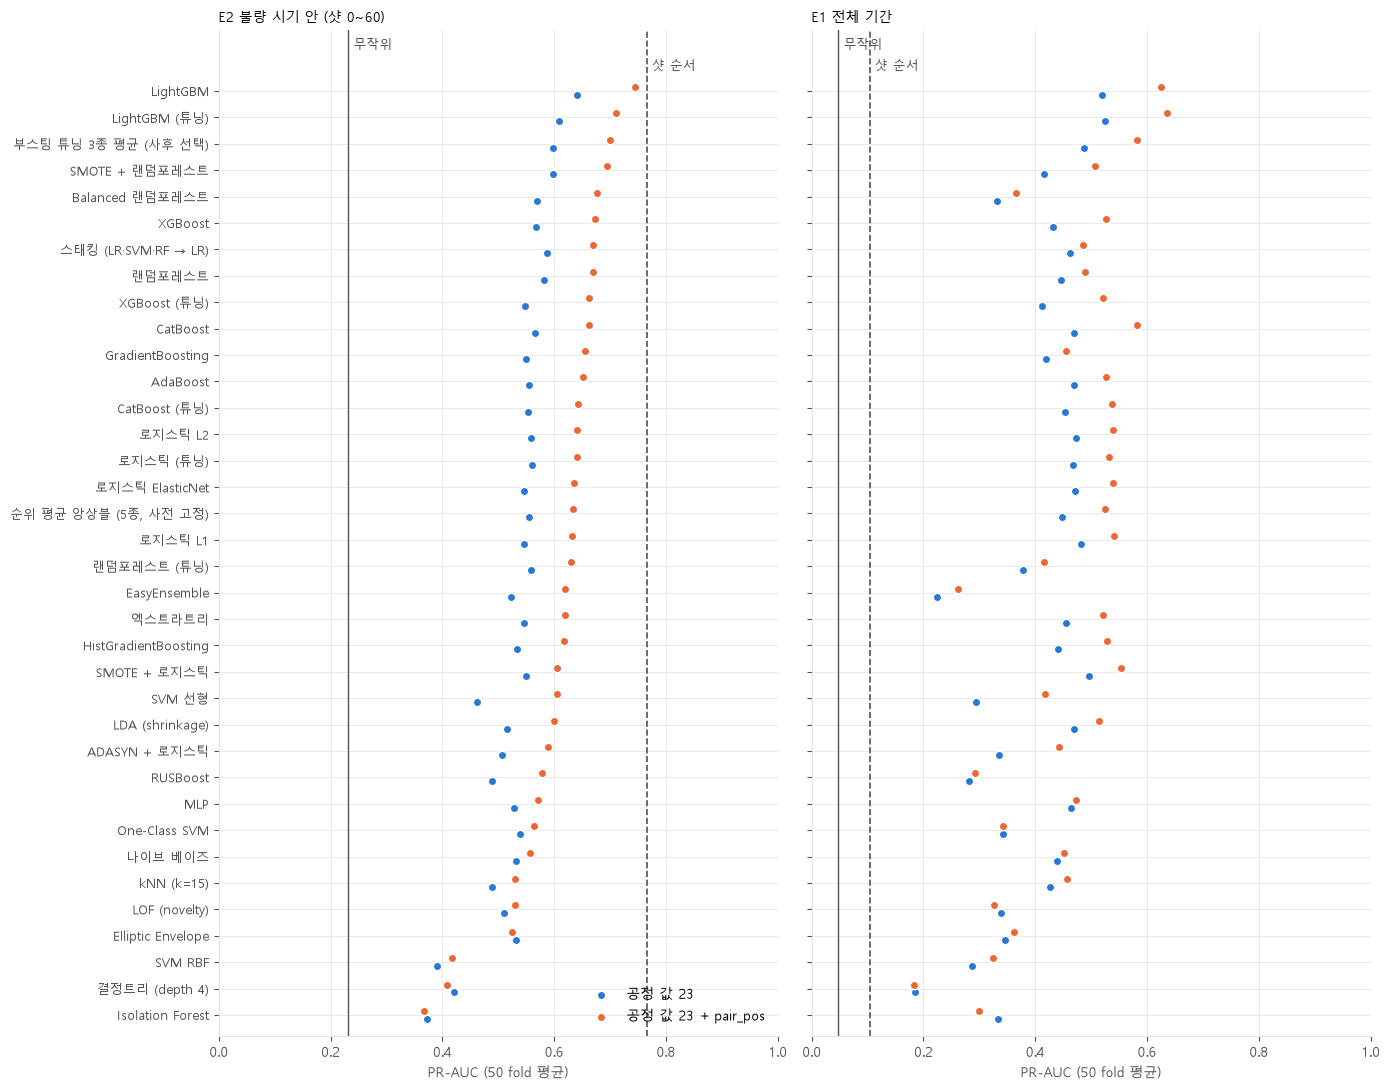

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 11), sharey=True)
order = (summary[(summary['eval'] == EVALS[1]) & (summary['features'] == '공정 값 23 + pair_pos')]
         .sort_values('PR-AUC_mean')['model'].tolist())
y = np.arange(len(order))
for ax, ev in zip(axes, [EVALS[1], EVALS[0]]):
    d = summary[summary['eval'] == ev]
    for feat, color, dy in [('공정 값 23', C_MAIN, -0.15), ('공정 값 23 + pair_pos', C_SUB, 0.15)]:
        v = d[d['features'] == feat].set_index('model')['PR-AUC_mean'].reindex(order)
        ax.scatter(v.values, y + dy, s=36, color=color, label=feat, zorder=3, edgecolor='white', linewidth=1)
    base = d[d['family'] == '기준선'].set_index('model')['PR-AUC_mean']
    ax.axvline(base['[기준] 샷 순서'], color=C_INK, linestyle='--', linewidth=1.2)
    ax.axvline(base['[기준] 무작위'], color=C_INK, linewidth=1)
    ax.text(base['[기준] 샷 순서'], len(order) - 0.3, ' 샷 순서', color=C_INK, fontsize=9, va='bottom')
    ax.text(base['[기준] 무작위'], len(order) + 0.5, ' 무작위', color=C_INK, fontsize=9, va='bottom')  # 샷 순서와 가까워도 겹치지 않게 한 줄 위
    ax.set_title(ev, loc='left')
    ax.set_xlabel('PR-AUC (50 fold 평균)')
    ax.set_xlim(0, 1)
axes[0].set_yticks(y, order, fontsize=9)
axes[0].set_ylim(-0.8, len(order) + 1.3)
axes[0].legend(loc='lower right', frameon=False)
plt.tight_layout()
Path('outputs/figures').mkdir(parents=True, exist_ok=True)
plt.savefig('outputs/figures/model_prauc.png', dpi=150, bbox_inches='tight')
plt.show()

### 읽는 법과 요약

**E2 불량 시기 안 (판정용)**

| | PR-AUC | Recall@10% | Recall@20% | Recall@30% | 검사율@재현율0.9 | 검사율@재현율1 |
|---|---|---|---|---|---|---|
| [기준] 무작위 | 0.23 | 0.11 | 0.23 | 0.30 | 91% | 96% |
| [기준] 쌍 순서 규칙 | 0.30 | 0.21 | 0.32 | 0.50 | 72% | 83% |
| **[기준] 샷 순서** | **0.77** | 0.60 | **0.84** | **0.92** | **29%** | **56%** |
| 최고: LightGBM (공정 값) | 0.64 | 0.51 | 0.68 | 0.81 | 45% | 58% |
| **최고: LightGBM (공정 값 + pair_pos)** | **0.75** | **0.61** | 0.78 | 0.90 | 38% | 75% |

- 36개 모델 모두 무작위·쌍 순서 규칙은 크게 넘는다. 하지만 **샷 순서 기준선을 확실히 넘는 모델은 없다.** 최고 모델(LightGBM + pair_pos)이 PR-AUC·Recall@10%에서 비슷하고, 나머지 지표에서는 샷 순서가 앞선다.
- 상위 10개 모델의 PR-AUC 차이(0.65~0.75)는 fold 간 표준편차(약 0.2)보다 훨씬 작다. 36개 중 1등을 고르는 것 자체가 낙관적이므로, "LightGBM이 확실히 최고"라기보다 **부스팅·랜덤포레스트 계열이 상위권**이라고 보는 것이 맞다.
- `pair_pos`를 넣으면 PR-AUC가 0.05~0.10 오른다 (해석 A 가정).

**E1 전체 기간 (참고)**
- 최고는 LightGBM (튜닝, + pair_pos) PR-AUC 0.64, 검사율@재현율0.9 **10%**. CatBoost (+ pair_pos)는 검사율@재현율0.9 **7%**.
- 샷 순서 기준선은 PR-AUC 0.10으로 낮지만 검사율@재현율0.9는 12%다. PR-AUC가 낮은 이유는 불량이 없는 샷 0~23도 맨 앞에 두기 때문이다. 모델은 이 초반 샷과 불량 샷(24~60)을 공정 값으로 구분해 PR-AUC가 높다.
- E1의 높은 성능은 `CN7.ipynb` 8-2 (b-2)대로 대부분 **"불량 시기 찾기"**다. 검사율 7~10%라는 숫자를 개별 불량 예측 성능으로 보고하면 과대평가다.

**계열별**
- **튜닝은 효과가 없었다.** E2에서 튜닝 버전이 기본 설정보다 오히려 낮다 (LightGBM 0.75 → 0.71). 학습 fold 불량 13~14개로 3-fold 튜닝을 하면 설정 비교 자체가 잡음이다.
- **앙상블도 단일 최고 모델을 넘지 못했다.** 사전 고정 5종 0.64, 사후 선택 부스팅 3종 0.70.
- **이상탐지(양품만 학습)는 두 평가 모두 하위권**이다 (E2 0.37~0.57). 불량이 "드문 공정 값"으로 나타나지 않는다.
- 스태킹은 샷 단위 내부 CV로 고친 뒤 정상 범위로 돌아왔다 (sklearn 기본 스태킹은 쌍 누수로 E2 ROC-AUC 0.47이었음).
- RUSBoost는 E2의 작은 학습 fold(불량 약 9개)에서 5~6개 fold 학습에 실패해, 성공한 fold만의 평균이다.

## 5. 공정 값은 시간 정보 이상을 담고 있나 (E2)

E2 안에서도 불량은 샷 48~60에 몰려 있어, 모델이 "늦은 샷일수록 위험"이라는 시간 흐름만 배웠을 수 있다. **샷 순서만 넣은 모델**과 **샷 순서 + 공정 값을 넣은 모델**의 PR-AUC를 같은 fold에서 비교한다.
- **조건부 순열검정**: 샷을 연속 10개씩 묶고, 묶음 안에서만 샷끼리 공정 값을 뒤섞는다(같은 샷의 두 부품은 같이 이동). 시간 흐름(10샷 단위)은 그대로 두고 "그 10샷 중 어느 샷이 불량인가"에 대한 공정 값 정보만 지운 기준이다. 실제 추가 기여가 이 기준의 95% 상한을 넘어야 공정 값이 시간 이상의 정보를 가진다고 본다.
- 계산량 때문에 순열검정은 2회 반복(10 fold) × 200번.

In [8]:
increment.round(3)

,PR-AUC 샷 순서만,PR-AUC 샷 순서 + 공정 값,추가 기여 (50 fold 평균),추가 기여가 양수인 fold 비율,추가 기여 (10 fold),순열 기준 평균 (10샷 창 안에서 섞음),순열 기준 95% 상한,순열 p
모델,,,,,,,,
로지스틱 L2,0.690,0.647,-0.043,0.12,-0.032,-0.176,-0.067,0.015
LightGBM,0.644,0.670,0.026,0.56,0.057,-0.030,0.025,0.005


→ **LightGBM에서는 공정 값이 시간 정보에 더해 작지만 유의한 정보를 준다.** 샷 순서만 넣은 모델보다 PR-AUC가 +0.03(50 fold 평균, 개선된 fold 56%), 순열검정용 10 fold에서 +0.06이다. 10샷 창 안에서 공정 값을 섞은 기준(95% 상한 +0.025)을 넘는다 (p = 0.005).
→ **로지스틱에서는 공정 값을 넣으면 오히려 낮아진다** (−0.04, 개선된 fold 12%). 다만 창 안에서 섞은 공정 값을 넣을 때(−0.18)보다는 덜 떨어져서 (p = 0.015) 공정 값에 정보가 전혀 없지는 않다. 선형 모델에는 23개 피처가 불량 121개 규모에 비해 많아 잡음이 더 크게 작용한 것으로 본다.
→ 즉 **CN7 공정 값에는 "시간 흐름"과 별개로 불량과 관련된 신호가 약하게 있다.** 그러나 그 크기는 시간 흐름 자체보다 작아서, 현재 데이터로는 시간 기준선을 넘는 모델을 만들 수 없었다.

> 참고: 이 표의 "샷 순서만" PR-AUC(0.64~0.69)는 모델이 샷 번호를 학습한 결과이고 동점 처리 방식도 달라서, 기준선 행의 0.77과 직접 비교하지 않는다. 비교는 같은 표 안에서만 한다.

## 6. 결론

**성능 (주 지표, E2 불량 시기 안 = 판정용)**
1. 36개 모델 중 최고는 **LightGBM (기본 설정, 공정 값 + `pair_pos`)**: PR-AUC 0.75 ± 0.20, Recall@10/20/30% = 0.61 / 0.78 / 0.90, 검사율@재현율0.9 = 38%.
2. 무작위(0.23)·쌍 순서 규칙(0.30)은 크게 넘지만 **샷 순서 기준선(0.77)을 넘지 못한다.** 불량 시기 안에서도 모델 성능의 대부분은 "늦은 샷일수록 위험"이라는 시간 흐름과 겹친다.
3. 다만 LightGBM에서 공정 값은 시간 흐름에 더해 **작지만 유의한 정보**를 준다 (PR-AUC +0.03~0.06, 조건부 순열 p = 0.005). 공정 값이 무의미한 것은 아니다.
4. 튜닝·앙상블·불균형 샘플링은 기본 설정 부스팅을 넘지 못했다. 불량 17개로는 복잡한 방법이 더하는 이득보다 추정 잡음이 크다.

**손익 분석용 (검사율@재현율)**
- E2: 재현율 0.9에 검사 38% (샷 순서 29%, 무작위 91%). 재현율 1.0은 58~75%로 흔들림이 크다 (가장 잡기 어려운 불량 1개가 결정).
- E1: 재현율 0.9에 검사 7~10%. **불량 시기 찾기가 섞인 값이라 손익 계산에 그대로 쓰면 과대평가다.** 손익 분석에는 E2 값을 보수적 기준으로 쓰는 것을 권한다.

**계획(1~5단계) 기준 판정**
- 2단계 "실패/성공" 판정: **부분 성공**. 무작위·쌍 순서 규칙 대비로는 성공이지만, 시간 기준선 대비로는 실패다. 모델을 바꾸는 것(이 노트북)으로는 더 끌어올리기 어렵다는 것이 이번 결과다.
- → 3단계(파생 변수·신규 데이터)로 넘어가는 것이 맞다.
  - **신규 데이터 1순위**: KAMP 원본 1차 가공 데이터(`TimeStamp`, `PART_NAME`). 불량 시기(샷 24~60)의 실제 시각과 쌍 순서 해석을 확인할 수 있고, 여러 불량 시기가 담긴 라벨이 있으면 시간 효과와 공정 신호를 분리할 수 있다.
  - **파생 변수**: 공정 값의 목표값 대비 편차, 금형 온도(3·4)·가소화 관련 변수의 변화율 등. 단 이전 샷 기반 파생 변수는 시간 정보를 더 강하게 담으므로(`CN7.ipynb` 4-3), 이 노트북의 **샷 순서 기준선과 추가 기여 검정을 그대로 적용**해 판정한다.
  - **TabPFN**: 라이선스 동의·로그인 후 `model_zoo.py`에 추가하면 같은 방식으로 비교할 수 있다.

**보고용 참고**
- 최종 후보: LightGBM (기본 설정). 상위권 모델 간 차이가 표준편차 안이라, 설명·재현이 쉬운 단일 모델을 고른다.
- 결과표: `outputs/tables/model_summary.csv` (전 모델·전 지표 평균·표준편차), fold별 `model_folds.csv`, 반복별 `model_inspection.csv`, 추가 기여 `time_increment.csv`. 그림: `outputs/figures/model_prauc.png`.